In [25]:
import numpy as np
import scipy as sp
from scipy.linalg import block_diag
from scipy.stats import unitary_group
from qutip import *
np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

import matplotlib.pyplot as plt

In [26]:
big = np.zeros((16,16))

In [27]:
small = np.array([[1,0,0,1],[0,0,0,0],[0,0,0,0],[2,0,0,2]])

In [28]:
small1 = np.zeros((6,6))
small1[0][0] = 1
small1[5][5] = 1

small2 = np.zeros((6,6))
small2[0][5] = 1
small2[5][0] = 1

In [29]:
big = np.zeros((16,16))

for i in range(int(big.shape[0])):#(int(big.shape[0]-small.shape[0])+1):
    for j in range(int(big.shape[1])):#(int(big.shape[0]-small.shape[0])+1):
        if i==j:
            if j<2:
                big[i:i+small2.shape[0],j:j+small2.shape[1]] = small2
            elif 2<= j <5:
                big[i:i+small1.shape[0],j:j+small1.shape[1]] = small1
            #elif j == 5:
                #big[i][j] = 0
            elif j>=1 + small2.shape[0]:
                big[i][j] = 1
            #if i!=0:
                #big[i*small.shape[0]:(i+1)*small.shape[0],j:j+small.shape[1]] = small

#big[4][4] = 0
'''
for i in range(int(big.shape[0])):#(int(big.shape[0]-small.shape[0])+1):
    for j in range(int(big.shape[1])):#(int(big.shape[0]-small.shape[0])+1):
        if i==j:
            if j<5:
                big[i:i+small.shape[0],j:j+small.shape[1]] = small2
            else:
                None
            #if i!=0:
                #big[i*small.shape[0]:(i+1)*small.shape[0],j:j+small.shape[1]] = small
    '''


'\nfor i in range(int(big.shape[0])):#(int(big.shape[0]-small.shape[0])+1):\n    for j in range(int(big.shape[1])):#(int(big.shape[0]-small.shape[0])+1):\n        if i==j:\n            if j<5:\n                big[i:i+small.shape[0],j:j+small.shape[1]] = small2\n            else:\n                None\n            #if i!=0:\n                #big[i*small.shape[0]:(i+1)*small.shape[0],j:j+small.shape[1]] = small\n    '

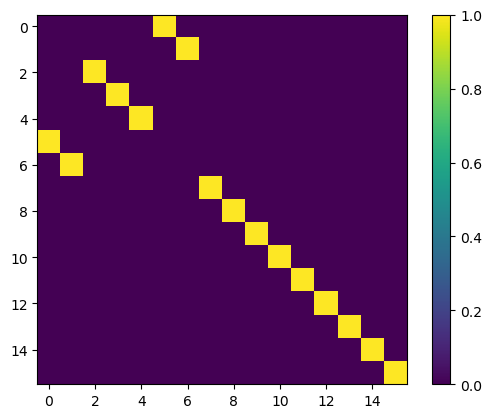

In [30]:
plt.imshow(big)
plt.colorbar()

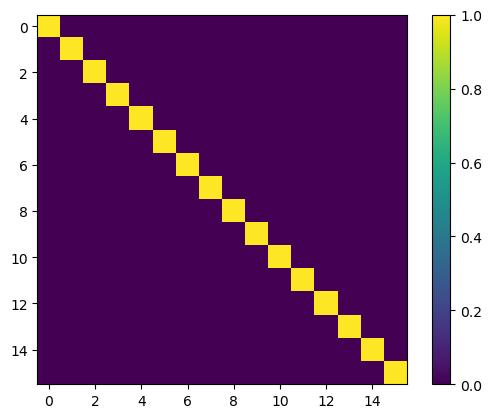

In [31]:
plt.imshow(big@big)
plt.colorbar()

In [32]:
#Gibbs energy dist from beta = 1 case, from the RSJJ model calculation value, single mode coup 1 gamma 1.4
Gibbs = np.array([[0.58412,0,0],[0,0.278235,0],[0,0,0.137646]])
degeneracy = np.array([3,3,3])

#Gibbs state with the degeneracy (Ergodic restriction concerned)
def degen_Gibbs_create(Gib, deg, TF):
    dim = Gib.shape[0]
    
    if dim == len(deg):
        sys_gibbs = []
        for i in range(dim):
        ###### debug ######
            #print(Gibbs[i][i])
            #print(degeneracy[i])
            #print("----------")
        ###### debug ######
            temp = (Gib[i][i], deg[i])
            div = temp[0]/temp[1]

            make_matrix_dim = np.identity(temp[1])
            make_matrix_dim *= div
            
            sys_gibbs.append(make_matrix_dim)
            ###### debug ######
            #print(sys_gibbs)
            ###### debug ######
        ret_matrix = block_diag(*sys_gibbs)
        if TF == False:
            return ret_matrix
        if TF == True:
            return sys_gibbs

    else:
        print("Not available input source")
        return None 

In [33]:
bath = degen_Gibbs_create(Gibbs,degeneracy,True)
#Create Qubit system with coherence
asdf = coherent_dm(2,0.8j)
sys = asdf.full()

gamma = np.sqrt(sys[0][0]/sys[1][1])

In [ ]:


sys_index = (sys.shape[0])
bath_index = len(bath)

gamma_1 = np.sqrt(1-gamma)
gamma_2 = np.sqrt(1-gamma**2)

#print("system_index",sys_index)

index_comb = []

for i in range(sys_index):
    for j in range(bath_index):
        comb = ((i,i),j)
        index_comb.append(comb)

sorted_comb = sorted(index_comb, key=lambda x: x[0][0] + x[1])
avail_values = [sorted_comb[i][0][0] + sorted_comb[i][1] for i in range(len(sorted_comb))] #possible combinations for indices corresponding energy conditions

value_bound = (min(avail_values),max(avail_values))
print("limited values : ", value_bound)

avail_values = avail_values[1:-1]
sorted_comb = sorted_comb[1:-1]
print("sorted result : ",sorted_comb)
print("avail_values : ",avail_values)

### zone divided structure construct ##
sub_block_arr = []
for k in range(len(sorted_comb)):
    sub_block = np.zeros(bath[sorted_comb[k][1]].shape[0])
    # This condition only acts under qubit case
    #print(sys[sorted_comb[k][0][0],sorted_comb[k][0][1]])
    sub_block = unitary_group.rvs(bath[sorted_comb[k][1]].shape[0])
    sub_block_arr.append(sub_block)
print("block divided zones")           
print(sub_block_arr)
#print(len(sub_block_arr))

arrsize = 0 
for l in range(len(sub_block_arr)):
    arrsize += sub_block_arr[l].shape[0]

total_block = np.zeros((arrsize,arrsize),dtype=np.complex128)

#create unitary subblock
for i in range(0,len(sub_block_arr),sys_index):
    si = sub_block_arr[i].shape[0]
    sector_block_1 = np.zeros((si+1,si+1))
    sector_block_2 = np.zeros((si+1,si+1))

    sector_block_1[0][si] = 1
    sector_block_1[si][0] = 1

    sector_block_2[0][0] = gamma
    sector_block_2[si][si] = gamma
    sector_block_2[0][si] = gamma_1
    sector_block_2[si][0] = -gamma_1

    sec1 = sector_block_1.shape[0]
    sec2 = sector_block_2.shape[0]

    for i in range(total_block.shape[0]):
        for j in range(total_block.shape[0]):
            if i==j:
                if j < 2:
                    total_block[i:i+sec1,j:j+sec1] = sector_block_1
                elif 2 <= j < sec1-1:
                    total_block[i:i+sec2,j:j+sec2] = sector_block_2
                elif j>=1 + sec2:
                    total_block[i][j] = 1

print(total_block)

tot_conju = total_block.conjugate().T

limited values :  (0, 3)
sorted result :  [((0, 0), 1), ((1, 1), 0), ((0, 0), 2), ((1, 1), 1)]
avail_values :  [1, 1, 2, 2]
block divided zones
[array([[ 0.162-0.113j, -0.723-0.123j, -0.208+0.617j],
       [-0.265-0.633j,  0.297-0.493j,  0.317+0.311j],
       [ 0.671-0.198j, -0.266-0.245j,  0.448-0.422j]]), array([[ 0.068+0.12j , -0.176-0.708j, -0.250-0.621j],
       [ 0.099+0.469j,  0.323-0.445j, -0.274+0.627j],
       [ 0.214-0.84j ,  0.327-0.242j, -0.249+0.145j]]), array([[-0.015+0.115j, -0.122+0.597j,  0.224+0.751j],
       [ 0.264-0.824j,  0.167+0.396j, -0.245-0.083j],
       [-0.453+0.18j , -0.217+0.63j , -0.033-0.563j]]), array([[-0.303-0.512j, -0.395-0.581j,  0.371+0.119j],
       [-0.579-0.397j,  0.614+0.157j, -0.019-0.324j],
       [ 0.279+0.272j,  0.227-0.232j,  0.660-0.554j]])]
[[ 0.000+0.j  0.000+0.j  0.000+0.j  1.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j]
 [ 0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  1.000+0.j  0.000+

C:\Users\sky12\AppData\Local\Temp\ipykernel_5312\524513243.py:54: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[0][0] = gamma
C:\Users\sky12\AppData\Local\Temp\ipykernel_5312\524513243.py:55: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[si][si] = gamma
C:\Users\sky12\AppData\Local\Temp\ipykernel_5312\524513243.py:56: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[0][si] = gamma_1
C:\Users\sky12\AppData\Local\Temp\ipykernel_5312\524513243.py:57: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[si][0] = -gamma_1


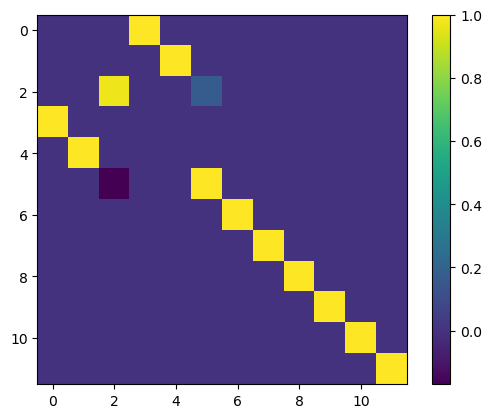

In [40]:
plt.imshow(total_block.real)
plt.colorbar()

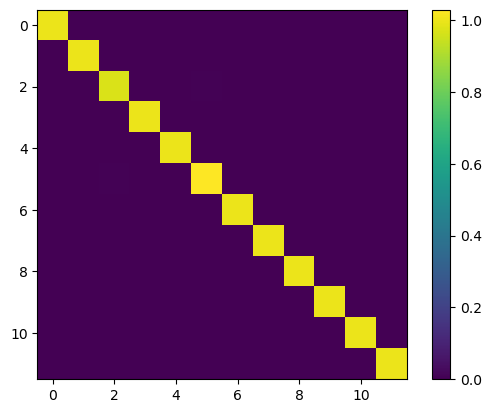

In [45]:
plt.imshow((total_block@tot_conju).real)
plt.colorbar()